# Performance Grid (2×5) — by Horizon × Feature Set

Goal: generate a **2×5 equity-curve grid** for PPT screenshots.
- Rows = horizons (1D, 3D)
- Columns = feature sets (F1…F5)

Each subplot overlays **models** (LR / RF / XGB) under one execution mode (close_to_close by default).

Data source: `outputs/curves/{TAG}_{MODE}_*.csv` produced by the pipeline (e.g., TAG=084).
No files are saved; plots are shown inline for screenshots.


In [5]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r'C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2')
OUT = ROOT / 'outputs'
CURVES = OUT / 'curves'

TAG = '084'
MODE = 'live'
EXEC_MODE = 'open_to_open'   # change to 'open_to_open' if needed

HORIZONS = [1, 3]
FEATURE_SETS = [
    'F1_momentum',
    'F2_momentum_reversal',
    'F3_plus_risk_liquidity',
    'F4_plus_cross_sectional',
    'F5_full_finance_no_fundamental',
]
MODELS = ['logistic_regression','random_forest','xgboost']

def load_curve(path: Path):
    d = pd.read_csv(path)
    d['date'] = pd.to_datetime(d['date'])
    d = d.sort_values('date')
    # Some curves might have NaNs; be safe
    d['net_ret'] = pd.to_numeric(d['net_ret'], errors='coerce')
    d = d.dropna(subset=['net_ret'])
    d['equity'] = (1 + d['net_ret']).cumprod()
    return d

def curve_path(feature_set: str, model: str, h: int, exec_mode: str):
    return CURVES / f'{TAG}_{MODE}_{feature_set}_{model}_{h}d_{exec_mode}_daily.csv'

def spy_path(h: int):
    return CURVES / f'{TAG}_{MODE}_SPY_{h}d_daily.csv'

def align_and_rebase(curves: dict):
    # Align all curves to overlapping date range & rebase to 1
    starts = [df['date'].min() for df in curves.values()]
    ends = [df['date'].max() for df in curves.values()]
    start = max(starts)
    end = min(ends)
    out = {}
    for name, df in curves.items():
        w = df[(df['date'] >= start) & (df['date'] <= end)].copy()
        w = w.sort_values('date')
        w['equity'] = w['equity'] / float(w['equity'].iloc[0])
        out[name] = w
    return out, start, end

print('Curves dir exists:', CURVES.exists(), CURVES)

Curves dir exists: True C:\Users\user\Downloads\Moltbot\HKU-FYP\fyp_finance_ml_v2\outputs\curves


## 2×5 grid
Each panel shows: SPY + (LR/RF/XGB) for that horizon & feature set.

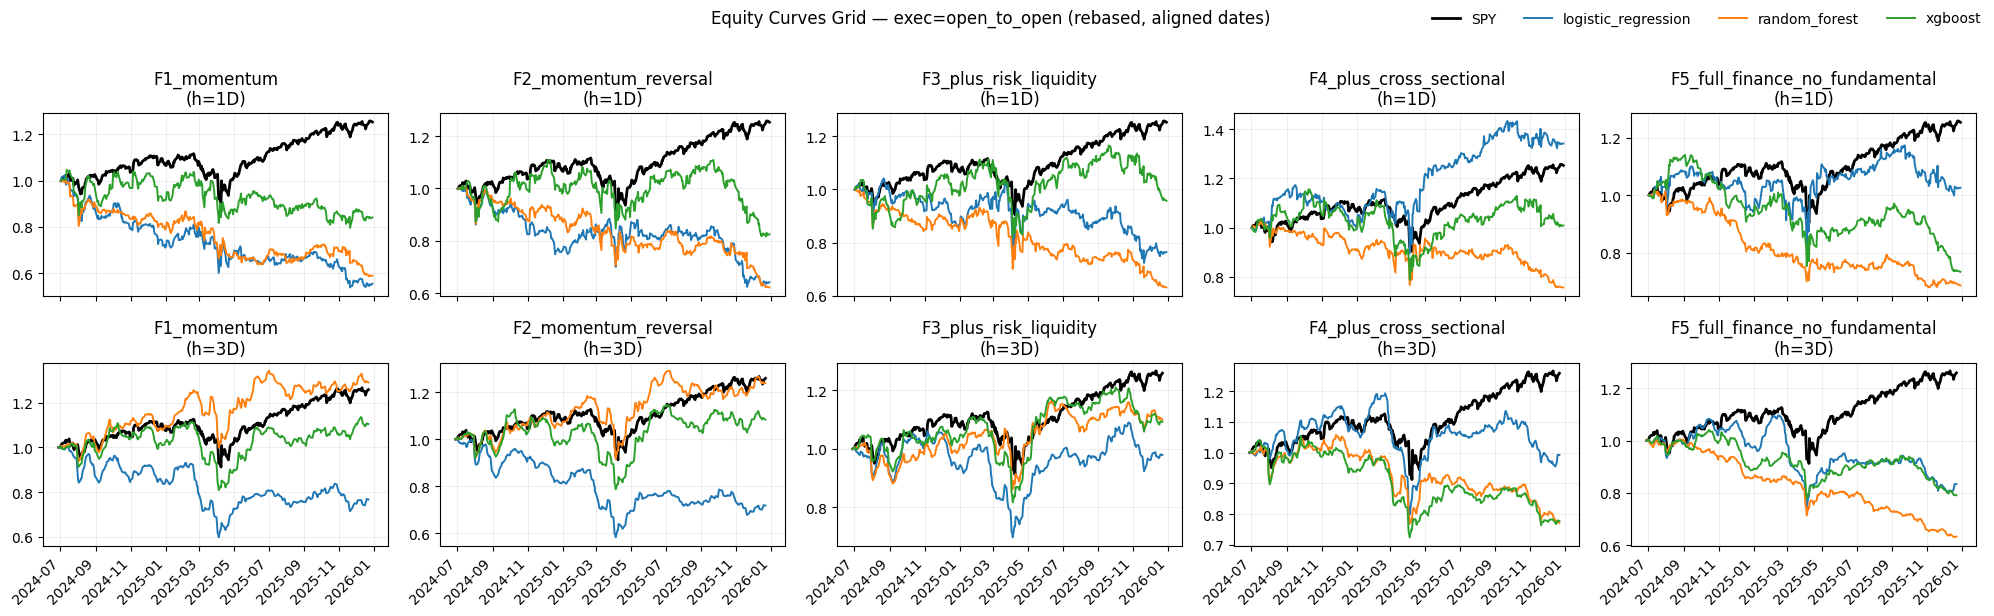

In [10]:
colors = {
    'SPY': 'black',
    'logistic_regression': '#1f77b4',
    'random_forest': '#ff7f0e',
    'xgboost': '#2ca02c',
}

fig, axes = plt.subplots(len(HORIZONS), len(FEATURE_SETS), figsize=(20, 6), sharex=True, sharey=False)

for r, h in enumerate(HORIZONS):
    spy_p = spy_path(h)
    spy = load_curve(spy_p) if spy_p.exists() else None

    for c, fs in enumerate(FEATURE_SETS):
        ax = axes[r, c] if len(HORIZONS) > 1 else axes[c]
        curves = {}

        if spy is not None:
            curves['SPY'] = spy

        for m in MODELS:
            p = curve_path(fs, m, h, EXEC_MODE)
            if p.exists():
                curves[m] = load_curve(p)

        if len(curves) < 2:
            ax.set_title(f'{fs}\n(h={h}D)')
            ax.text(0.5, 0.5, 'missing curves', ha='center', va='center', transform=ax.transAxes)
            ax.grid(True, alpha=0.2)
            continue

        curves_a, start, end = align_and_rebase(curves)

        for name, dfc in curves_a.items():
            lw = 2 if name == 'SPY' else 1.4
            ax.plot(dfc['date'], dfc['equity'], label=name, linewidth=lw, color=colors.get(name, None))

        ax.set_title(f'{fs}\n(h={h}D)')
        ax.grid(True, alpha=0.2)
        if r == len(HORIZONS)-1:
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)
                tick.set_ha('right')

# Legend once
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncols=4, frameon=False)
plt.suptitle(f'Equity Curves Grid — exec={EXEC_MODE} (rebased, aligned dates)', y=1.02)
plt.tight_layout()
plt.show()

## Optional: show which curves are missing
Useful for debugging if some panels say "missing curves".

In [ ]:
missing = []
for h in HORIZONS:
    for fs in FEATURE_SETS:
        for m in MODELS:
            p = curve_path(fs, m, h, EXEC_MODE)
            if not p.exists():
                missing.append((h, fs, m, str(p.name)))

pd.DataFrame(missing, columns=['horizon','feature_set','model','file']).head(50)